In [4]:
# Import Libraries
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
import numpy as np
import pandas as pd
import cv2
import json
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

2025-10-07 17:29:06.102707: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759836546.267261  695345 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759836546.310739  695345 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1759836546.739982  695345 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1759836546.740173  695345 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1759836546.740179  695345 computation_placer.cc:177] computation placer alr

In [2]:
# Parameters
IMG_SIZE = 128
DATA_PATH = "../Data/Scores"
BATCH_SIZE = 32
EPOCHS = 20

In [3]:
# Load Dataset
print("[INFO] Loading dataset...")
X, y, class_names = [], [], []
class_map = {}

for shape_name in os.listdir(DATA_PATH): 
    shape_path = os.path.join(DATA_PATH, shape_name)
    if not os.path.isdir(shape_path):
        continue
    
    for score in os.listdir(shape_path): 
        score_path = os.path.join(shape_path, score)
        if not os.path.isdir(score_path):
            continue
        
        label = f"{shape_name}_{score}"
        if label not in class_map:
            class_map[label] = len(class_map)
            class_names.append(label)
        
        for file in os.listdir(score_path):
            if file.endswith(".png") or file.endswith(".jpg"):
                path = os.path.join(score_path, file)
                img = cv2.imread(path)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                X.append(img)
                y.append(class_map[label])

X = np.array(X, dtype="float32") / 255.0
y = np.array(y)
y_cat = to_categorical(y, num_classes=len(class_map))

print(f"[INFO] Dataset loaded: {X.shape[0]} samples, {len(class_map)} classes")

[INFO] Loading dataset...
[INFO] Dataset loaded: 4297 samples, 34 classes


In [4]:
# Train-Test Split
print("[INFO] Splitting dataset...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat,
    test_size=0.2,
    random_state=42
)

print(f"[INFO] Train: {X_train.shape}, Test: {X_test.shape}")
print("[INFO] Classes:", class_names)

[INFO] Splitting dataset...
[INFO] Train: (3437, 128, 128, 3), Test: (860, 128, 128, 3)
[INFO] Classes: ['Triangle_0', 'Triangle_4', 'Triangle_5', 'Star_3', 'Star_2', 'Star_0', 'Star_4', 'Star_5', 'Wave_3', 'Wave_2', 'Wave_0', 'Wave_4', 'Circle_3', 'Circle_2', 'Circle_0', 'Circle_4', 'Square_0', 'Square_4', 'Square_5', 'Overlapped pencils_3', 'Overlapped pencils_2', 'Overlapped pencils_0', 'Overlapped pencils_4', 'Overlapped pencils_6', 'Overlapped pencils_5', 'Overlapped circle_2', 'Overlapped circle_0', 'Overlapped circle_4', 'Overlapped circle_6', 'Overlapped circle_5', 'Diagonal_3', 'Diagonal_0', 'Diagonal_4', 'Diagonal_5']


In [5]:
# Build EfficientNetV2 Model
base_model = EfficientNetV2B0(include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3), weights=None)

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(len(class_map), activation="softmax") 
])

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

print(model.summary())

2025-10-07 11:19:55.828747: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-b0 (Functional)  │ (None, 4, 4, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 34)             │        43,554 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,962,866 (22.75 MB)

 Trainable params: 5,902,258 (22.52 MB)

 Non-trainable params: 60,608 (236.75 KB)

None


In [7]:
# Callbacks
#early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
#reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-6)

In [11]:
# Train
print("[INFO] Training EfficientNetV2...")
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

[INFO] Training EfficientNetV2...
Epoch 1/20


2025-10-07 11:37:31.375891: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 540475392 exceeds 10% of free system memory.


86/86 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step - accuracy: 0.1225 - loss: 2.7025 - val_accuracy: 0.0785 - val_loss: 3.3318
Epoch 2/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step - accuracy: 0.1603 - loss: 2.6083 - val_accuracy: 0.1381 - val_loss: 2.7140
Epoch 3/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step - accuracy: 0.1839 - loss: 2.5636 - val_accuracy: 0.0945 - val_loss: 2.8207
Epoch 4/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.1862 - loss: 2.4816 - val_accuracy: 0.0625 - val_loss: 91.0096
Epoch 5/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.4521 - loss: 1.8605 - val_accuracy: 0.0451 - val_loss: 600.1462
Epoch 6/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step - accuracy: 0.6177 - loss: 1.3106 - val_accuracy: 0.0654 - val_loss: 276.6822
Epoch 7/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step - accuracy: 0.6890 - loss: 0.9928 - val_accuracy: 0.1076 - val_loss: 44.2391
Epoch 8/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step - accuracy: 0.7147 - loss: 0.8764 - val_accuracy: 0.0799 - val_loss: 240.

In [12]:
# Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n[RESULT] EfficientNetV2 Test Accuracy: {test_acc:.4f}")


[RESULT] EfficientNetV2 Test Accuracy: 0.1651


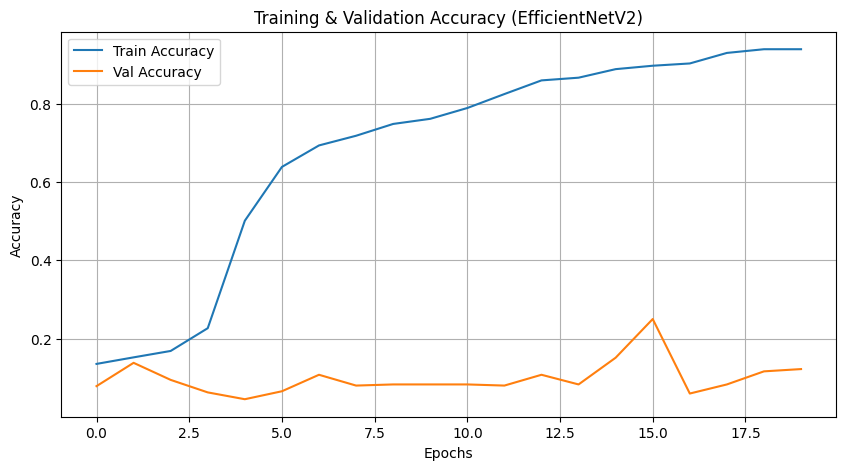

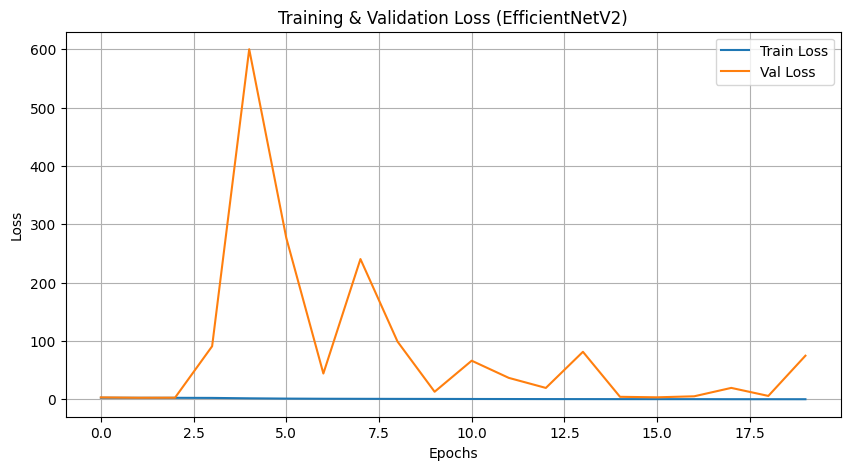

In [13]:
# Plot Accuracy & Loss
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Training & Validation Accuracy (EfficientNetV2)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training & Validation Loss (EfficientNetV2)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [6]:
# Save Model
SAVE_DIR = "./model_outputs/efficientnetV2"
os.makedirs(SAVE_DIR, exist_ok=True)

In [15]:
# Accuracy Plot
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(SAVE_DIR, "accuracy_plot.png"))
plt.close()

In [16]:
# Save Loss Plot
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(SAVE_DIR, "loss_plot.png"))
plt.close()

In [7]:
# Save trained model
model.save(os.path.join(SAVE_DIR, "efficientnetV2_bot2_model.h5"))
print("[INFO] Model saved successfully")

NameError: name 'model' is not defined

In [8]:
# Save training history as JSON
with open(os.path.join(SAVE_DIR, "training_history_efficientnetV2.json"), "w") as f:
    json.dump(history.history, f)
print("[INFO] Training history saved as JSON")

NameError: name 'history' is not defined

In [9]:
# Save
pd.DataFrame(history.history).to_csv(os.path.join(SAVE_DIR, "global_efficientnetV2_training_history.csv"), index=False)

NameError: name 'history' is not defined